In [14]:
import numpy as np

import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit ,transpile
from qiskit_aer import AerSimulator
from itertools import product
from qiskit_aer import Aer

In [5]:
img_data = np.array([0, 255, 128, 64]).reshape(2, 2)
img_w, img_h = img_data.shape[0], img_data.shape[1]
pixel_num = img_w * img_h


# Normalize image
img_max = np.max(img_data)
norm_img = img_data / img_max
norm_sq = norm_img**2
norm_sq_sum = np.sum(np.sum(norm_sq, axis=1))
norm_sq_sum_root = np.sqrt(norm_sq_sum)
temp = norm_img / norm_sq_sum_root

# Reshape to column vector
amplitude_encoded_image = temp.reshape(pixel_num, 1)


num_qubits = int(np.log2(img_w * img_h))
total_states = 2**num_qubits
# Reshape to 1D array for Qiskit (required format)
amplitude_encoded_image = amplitude_encoded_image.reshape(int(total_states))

# Verify normalization (sum of squared amplitudes should be 1)
print(f"Sum of squared amplitudes: {np.sum(np.abs(amplitude_encoded_image)**2):.6f}")
print(f"Shape of amplitude encoded image: {amplitude_encoded_image.shape}")
print(f"Number of qubits: {num_qubits}")
print(f"Total states: {total_states}")
print(f"Pixel values: {amplitude_encoded_image[:pixel_num]}")


Sum of squared amplitudes: 1.000000
Shape of amplitude encoded image: (4,)
Number of qubits: 2
Total states: 4
Pixel values: [0.         0.8720561  0.43773796 0.21886898]


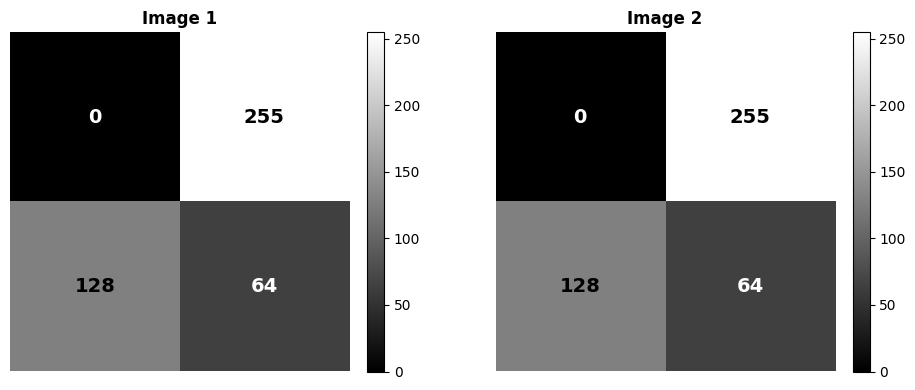

In [6]:
display_image(img_data, img_data)

## Quantum Probability Image Encoding (QPIE)
https://arxiv.org/pdf/1801.01465.pdf

Quantum Circuit:


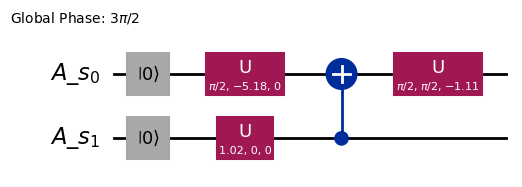

In [45]:
alice_state_register = QuantumRegister(num_qubits, 'A_s') 

classical_measure = ClassicalRegister(num_qubits, 'cm') 

qc = QuantumCircuit(alice_state_register)

# Initialize quantum circuit to the amplitude-encoded state
qc.initialize(amplitude_encoded_image, range(0, num_qubits))

# Visualize the circuit
print("Quantum Circuit:")

qc.decompose().decompose().decompose().decompose().decompose().draw('mpl', fold=1000)




Measurement results (1000 shots):
{'11': 4663, '10': 18997, '01': 76340}


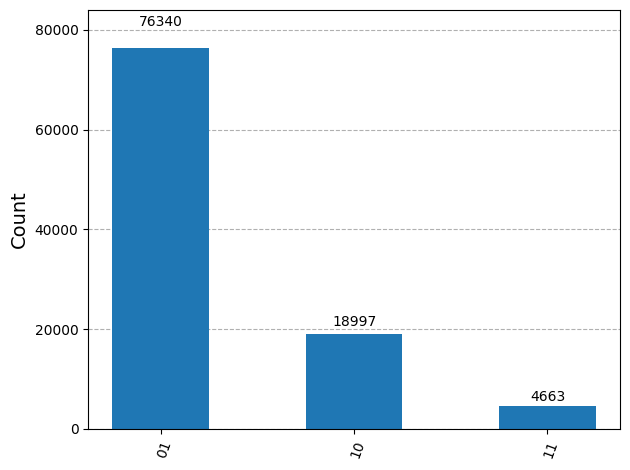

In [46]:
# Simulate and measure to verify encoding
simulator = AerSimulator()
qc.measure_all()  # Measure all qubits
compiled_circuit = transpile(qc, simulator)
job = simulator.run(compiled_circuit, shots=100000)
result = job.result()
counts = result.get_counts(compiled_circuit)

print("\nMeasurement results (1000 shots):")
print(counts)

# Plot histogram
plot_histogram(counts)

In [47]:
from math import pi


sorted_statistics = dict(sorted(counts.items(), key=lambda x: x[0]))
print(sorted_statistics)
amplitudes = np.array(list(dict(sorted_statistics).values()))
print(amplitudes)
probabilities = amplitudes/np.sum(amplitudes)
print(probabilities)
pixel_values = np.sqrt(probabilities)*255
pixel_values = np.insert(pixel_values, 0, 0).reshape(img_w, img_h)
print(pixel_values)


{'01': 76340, '10': 18997, '11': 4663}
[76340 18997  4663]
[0.7634  0.18997 0.04663]
[[  0.         222.80054982]
 [111.14314756  55.06465064]]


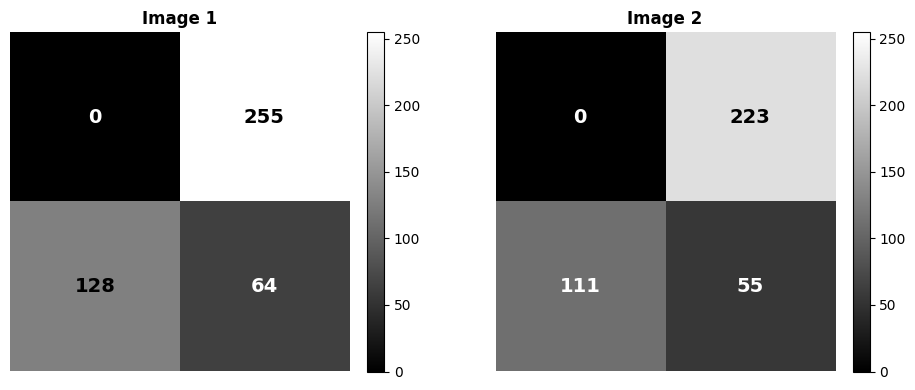

In [48]:
display_image(img_data, pixel_values)

In [4]:
def display_image(img1, img2, title1='Image 1', title2='Image 2', vmin1=0, vmax1=255, vmin2=0, vmax2=255):
    """
    Display two images side by side.
    
    Parameters:
    - img1: First image array (2D numpy array)
    - img2: Second image array (2D numpy array)
    - title1: Title for first image (default: 'Image 1')
    - title2: Title for second image (default: 'Image 2')
    - vmin1, vmax1: Value range for first image colormap
    - vmin2, vmax2: Value range for second image colormap
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Display first image
    im1 = axes[0].imshow(img1, cmap='gray', vmin=vmin1, vmax=vmax1)
    axes[0].set_title(title1, fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Add pixel values as text annotations for first image
    for i in range(img1.shape[0]):
        for j in range(img1.shape[1]):
            threshold = (vmax1 - vmin1) / 2
            axes[0].text(j, i, f'{img1[i, j]:.0f}' if vmax1 > 1 else f'{img1[i, j]:.3f}', 
                        ha='center', va='center', 
                        color='white' if img1[i, j] < threshold else 'black',
                        fontsize=14, fontweight='bold')
    
    plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

    # Display second image
    im2 = axes[1].imshow(img2, cmap='gray', vmin=vmin2, vmax=vmax2)
    axes[1].set_title(title2, fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    # Add pixel values as text annotations for second image
    for i in range(img2.shape[0]):
        for j in range(img2.shape[1]):
            threshold = (vmax2 - vmin2) / 2
            axes[1].text(j, i, f'{img2[i, j]:.0f}' if vmax2 > 1 else f'{img2[i, j]:.3f}', 
                        ha='center', va='center', 
                        color='white' if img2[i, j] < threshold else 'black',
                        fontsize=14, fontweight='bold')
    
    plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Mathematical process of the quantum circuit
from scipy.linalg import kron

# U gate matrix: U(θ, φ, λ)
def U_gate(theta, phi, lam):
    c, s = np.cos(theta/2), np.sin(theta/2)
    return np.array([[c, -np.exp(1j*lam)*s],
                     [np.exp(1j*phi)*s, np.exp(1j*(phi+lam))*c]])

# CNOT matrix (control=A_s0, target=A_s1)
CNOT = np.array([[1,0,0,0], [0,1,0,0], [0,0,0,1], [0,0,1,0]])

# Initial state |00⟩
psi = np.array([1, 0, 0, 0], dtype=complex)

# Step 1: Apply U gates
U1 = U_gate(np.pi/2, -5.18, 0)  # A_s0
U2 = U_gate(1.02, 0, 0)         # A_s1
psi = kron(U1, U2) @ psi

print(psi)
# # Step 2: Apply CNOT
# psi = CNOT @ psi

# # Step 3: Apply final U on A_s0
# U3 = U_gate(np.pi/2, np.pi/2, -1.11)
# psi = kron(U3, np.eye(2)) @ psi

# # Step 4: Measurement probabilities
# probs = np.abs(psi)**2
# print("Final state vector:")
# print(psi)
# print("\nMeasurement probabilities:")
# for i, state in enumerate(['00', '01', '10', '11']):
#     print(f"P(|{state}⟩) = {probs[i]:.6f}")

[0.61712356+0.j         0.34519344+0.j         0.27817156+0.55087391j
 0.15559769+0.30813612j]


/var/folders/k3/7j99y50d12x5lcw5cmlwtdmr0000gn/T/ipykernel_3072/32314238.py:19: DeprecationWarning: `kron` has been deprecated in favour of `numpy.kron` in SciPy 1.15.0 and will be removed in SciPy 1.17.0.
  psi = kron(U1, U2) @ psi


## NEQR: Quantum Image Encoding with Binary Intensity Representation

### Equation (7): Basic Quantum Image State

$$|I\rangle = \frac{1}{\sqrt{N}}\sum_{x=0}^{N-1}\sum_{y=0}^{N-1} I(x, y) |x\rangle|y\rangle$$

Where:
- \(|x\rangle\) and \(|y\rangle\) are quantum position registers encoding spatial coordinates
- \(I(x, y)\) represents the pixel intensity at position \((x, y)\)
- **Pixel intensities are encoded as amplitudes** of position basis states

This enables parallel processing of all pixel intensities simultaneously.

### Equation (8): Binary Representation of Pixel Intensity

$$|I(x, y)\rangle = \frac{1}{\sqrt{L}}\sum_{i=0}^{L-1} I_i(x, y) |i\rangle$$

**What does \(i\) mean?**

- **\(i\) is the bit position index** (0 to L-1)
- **\(I_i(x, y)\) is the \(i\)-th bit** of the binary representation of pixel intensity at position \((x, y)\)
- **\(L\) is the number of qubits** needed to represent intensity (for 8-bit: L = 8, not 256)
- **\(|i\rangle\) represents the \(i\)-th qubit** in the intensity register

**Example for 8-bit intensity:**
- If \(I(x, y) = 150\) (binary: `10010110`)
- Then: \(I_0(x, y) = 0\), \(I_1(x, y) = 1\), \(I_2(x, y) = 1\), \(I_3(x, y) = 0\), \(I_4(x, y) = 1\), \(I_5(x, y) = 0\), \(I_6(x, y) = 0\), \(I_7(x, y) = 1\)
- The state \(|I(x, y)\rangle = |10010110\rangle\) encodes all 8 bits simultaneously

### Equation (9): Complete NEQR State

$$|I\rangle = \frac{1}{\sqrt{N}}\sum_{x=0}^{N-1}\sum_{y=0}^{N-1}\sum_{i=0}^{L-1} I_i(x, y) |x\rangle|y\rangle|i\rangle$$

This combines:
- **Position encoding**: \(|x\rangle|y\rangle\) (spatial coordinates)
- **Intensity encoding**: \(|i\rangle\) (binary representation of intensity)
- **All pixels and all bits** in superposition

In [ ]:
# Minimal NEQR: Encode → Measure → Reconstruct
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

# 2x2 image: [0, 255, 128, 64] at positions (0,0), (0,1), (1,0), (1,1)
img = np.array([[0, 255], [128, 64]])
print("Original Image:")
print(img)

# NEQR: 10 qubits (2 position + 8 intensity)
# Create superposition: |I⟩ = (1/2) Σ |I(x,y)⟩|x⟩|y⟩
positions = [(0,0), (0,1), (1,0), (1,1)]
intensities = [0, 255, 128, 64]

# Build state vector: Qiskit uses qubit 0 as LSB
# Qubits 0-1: position (x, y), Qubits 2-9: intensity
state_vector = np.zeros(2**10, dtype=complex)
amplitude = 1/2

for (x, y), I in zip(positions, intensities):
    # Position: qubits 0-1 (LSB)
    pos_state = (x << 1) | y
    
    # State index: intensity in upper 8 bits, position in lower 2 bits
    # In Qiskit: index = Σ(qubit_i × 2^i), so qubit 0 is bit 0
    state_index = (I << 2) | pos_state
    state_vector[state_index] = amplitude

# Normalize
state_vector = state_vector / np.linalg.norm(state_vector)

# Create circuit
qc = QuantumCircuit(10, 10)
qc.initialize(state_vector, range(10))
qc.measure_all()

# Simulate
simulator = AerSimulator()
job = simulator.run(qc, shots=1000)
counts = job.result().get_counts()

# Verify state vector
print("\nState vector verification:")
print("Expected bit layout: [intensity(8 bits)][x(1 bit)][y(1 bit)]")
for (x, y), I in zip(positions, intensities):
    pos_state = (x << 1) | y
    state_index = (I << 2) | pos_state
    # Convert to binary to verify
    binary_repr = format(state_index, '010b')
    # Parse back to verify
    y_check = state_index & 1
    x_check = (state_index >> 1) & 1
    intensity_check = state_index >> 2
    print(f"  Position ({x},{y}), Intensity {I:3d}: state_index={state_index:4d}, binary={binary_repr}")
    print(f"    Parsed back: x={x_check}, y={y_check}, intensity={intensity_check}")
    
print(f"\nTotal non-zero amplitudes: {np.count_nonzero(state_vector)}")
print(f"Sum of squared amplitudes: {np.sum(np.abs(state_vector)**2):.6f}")

# Reconstruct: Qiskit bitstrings have qubit 0 as rightmost (LSB)
reconstructed = np.zeros((2, 2), dtype=int)
position_counts = {}  # Track all measurements per position

print(f"\nTotal measurements: {len(counts)}")
print("Sample bitstring format check (first 3):")
for i, (bitstring, count) in enumerate(list(counts.items())[:3]):
    print(f"  Raw bitstring: '{bitstring}' (length={len(bitstring)})")

for bitstring, count in counts.items():
    # Handle bitstring format - remove spaces and take first 10 bits
    bitstring_clean = bitstring.replace(' ', '')
    
    # Take only the first 10 bits (in case there are extra)
    if len(bitstring_clean) >= 10:
        bitstring_clean = bitstring_clean[:10]
    else:
        print(f"Warning: Bitstring too short: {bitstring}")
        continue
    
    # Qiskit bitstring: bitstring[0] = qubit 9 (MSB), bitstring[9] = qubit 0 (LSB)
    # Convert to integer to extract bits correctly
    state_index = int(bitstring_clean, 2)
    
    # Extract: state_index = (intensity << 2) | (x << 1) | y
    y = state_index & 1           # Bit 0
    x = (state_index >> 1) & 1     # Bit 1
    intensity = state_index >> 2    # Bits 2-9
    
    # Store all measurements for each position
    if (x, y) not in position_counts:
        position_counts[(x, y)] = {}
    position_counts[(x, y)][intensity] = position_counts[(x, y)].get(intensity, 0) + count

# Use most frequent intensity for each position
for (x, y), intensity_dict in position_counts.items():
    most_frequent = max(intensity_dict.items(), key=lambda x: x[1])
    reconstructed[x, y] = most_frequent[0]

# Check if all positions were measured
print("\nReconstructed Image:")
print(reconstructed)
print("\nMeasurement summary per position:")
for (x, y) in positions:
    if (x, y) in position_counts:
        top3 = dict(sorted(position_counts[(x,y)].items(), key=lambda x: x[1], reverse=True)[:3])
        total_shots = sum(position_counts[(x,y)].values())
        print(f"  Position ({x},{y}): {top3} (total={total_shots} shots)")
    else:
        print(f"  Position ({x},{y}): NOT MEASURED")

print(f"\nTop 4 measurements:")
for bitstring, count in sorted(counts.items(), key=lambda x: x[1], reverse=True)[:4]:
    bitstring_clean = bitstring.replace(' ', '')[:10]
    if len(bitstring_clean) == 10:
        state_index = int(bitstring_clean, 2)
        y = state_index & 1
        x = (state_index >> 1) & 1
        intensity = state_index >> 2
        print(f"  {bitstring_clean}: {count} shots → pos=({x},{y}), intensity={intensity}")
    else:
        print(f"  {bitstring}: {count} shots (cleaned length={len(bitstring_clean)})")

Original Image:
[[  0 255]
 [128  64]]
[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]


1020
1023
